In [2]:
from astropy import constants, units
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import scipy 
from scipy import signal
from scipy.fft import fft, fftshift
from astropy.units import Quantity
from astropy import units
import matplotlib.ticker as ticker
import cmcrameri.cm as cmc
import sys

import hera_sim
from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.plot import waterfall
from uvtools.utils import FFT, fourier_freqs

from astropy import units as u
mpl.rcParams['font.size']=20
from plotting_codes.plotting_functions import plot_waterfalls,plot_waterfalls_from_dlfr
from functions import covariance_from_pspec,sys_modes,fourier_operator

# Setup

In [3]:
# Check power spectrum
def calc_ps(s):
    # NOTE: This uses inverse FFT instead of FFT to get the right normalisation
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs # CHECK: This takes an average

In [7]:
result_dir='paper_plots/'
# run_version = 'low_dl_fr_0'
run_version = 'high_dl_fr_0'
# run_version = 'low_dl_low_fr'
# run_version = 'fixed_sky'

# Build systematics model
# nm_list = [(3,0),(4,0),(5,0),(6,0)] #low dl fr 0
nm_list = [(10,0), (11,0), (12,0), (13,0)] #high dl fr 0
# nm_list = [(3,3),(3,4),(3,5),(3,6)] #low dl low fr



Ntimes = 80 #60 #203
Nfreqs = 60
freqs = np.linspace(100., 120., 120) ##120) 
Nfgmodes = 12
freqs = freqs[:Nfreqs]
# Generate FG mode matrix
fgmodes = np.array([
                scipy.special.legendre(i)(np.linspace(-1., 1., freqs.size))
                for i in range(Nfgmodes)
            ]).T

lsts = np.linspace(0., 1., Ntimes)
sys_modes_operator = sys_modes(freqs_Hz=freqs*1e6, 
                                    times_sec=lsts * 24./(2.*np.pi) * 3600., 
                                    modes=nm_list)

sys_amps_true = np.array([4., 4.1, 5., -2.]) #np.array([4., 4.01])
sys_prior = 4**2. * np.eye(sys_amps_true.size)

fourier_op = fourier_operator(freqs.size, unitary=True)

# Generate noise
noise_ps_val = 0.000004 #0.000004 # 0.0004
noise_ps_true = noise_ps_val * np.ones(freqs.size)
N_true = covariance_from_pspec(noise_ps_true, fourier_op)
Ninv = np.diag(1./np.diag(N_true)) # get diagonal, invert, pack back into diagonal
n = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes) 
                    + 1.j*np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)
# Note factor of sqrt(2) above
noise_ps_check = calc_ps(n.T)

# Plotting masked and filtered data

In [8]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams.update({'font.size': 20})

In [9]:
# eor_true=np.load('/Users/user/Documents/Codes/hydra_sys_project1/multi_phil/hydra-pspec-systematic/npy_data/eor_true.npy')
eor_true=np.load(result_dir+run_version+'/eor_true.npy')
fg_true=np.load('./npy_data/fg_true.npy')
# sys_model_true=np.load(result_dir+run_version+'true_gain.npy') #1+delta_g has been saved
sys_model_true= (1+(sys_modes_operator @ sys_amps_true)).reshape((Ntimes, Nfreqs),order='F')
ps_true = calc_ps(eor_true[:Ntimes,:Nfreqs])
fg_true=fg_true[:Ntimes,:Nfreqs]

data_true = sys_model_true * (fg_true + eor_true)

## Plotting data 

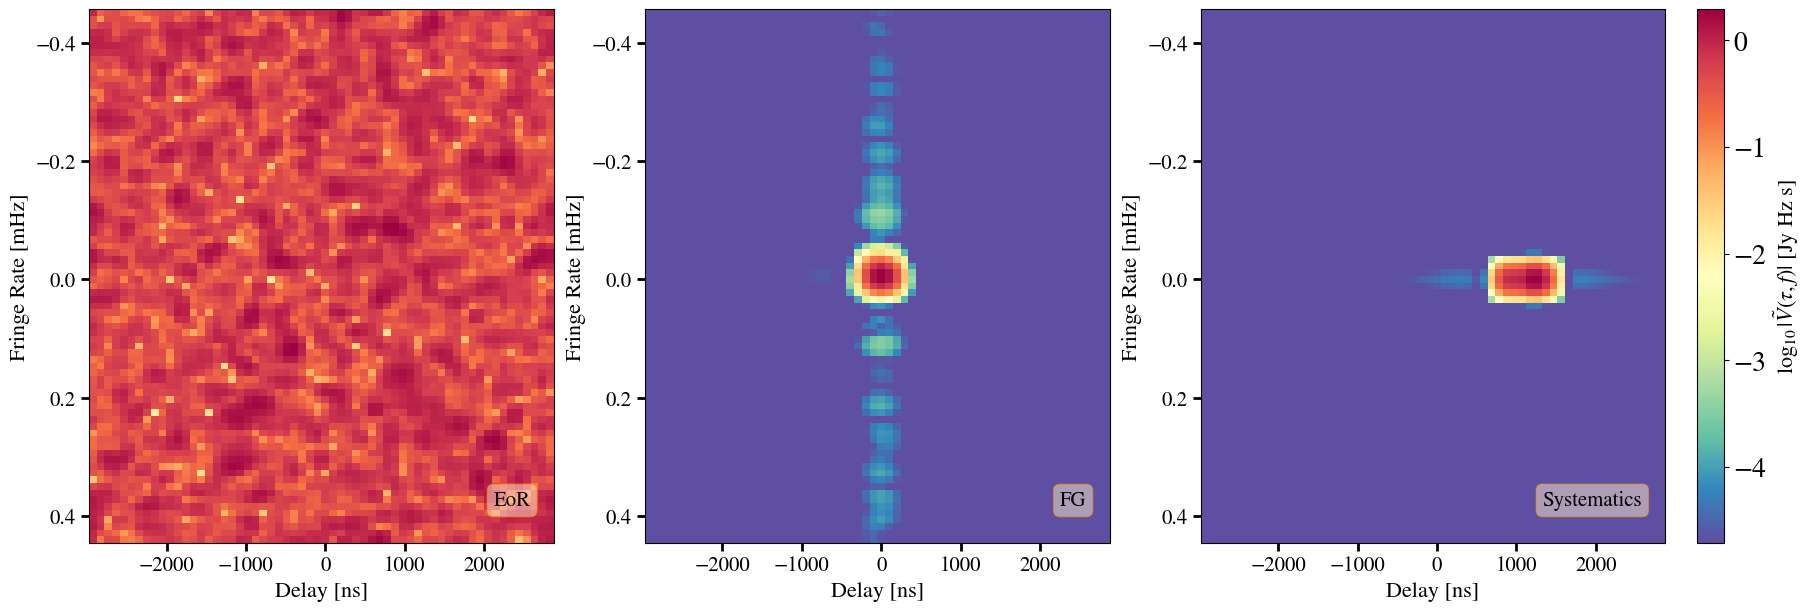

In [10]:
fig,axs = plt.subplots(1,3,layout="constrained",figsize=(18,6))
bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
i=0
data_arr=[eor_true,fg_true,((sys_modes_operator @ sys_amps_true)).reshape((Ntimes, Nfreqs),order='F')]
fig_labels = ['EoR','FG','Systematics']
plot_op=plot_waterfalls(data_arr[0], freqs*1e6, lsts, windows='blackman-harris', fig=fig,ax=axs[0], mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=False,
                freq_window_kwargs=None, time_window_kwargs=None)
axs[0].text(0.95,0.07,fig_labels[0],fontsize=15, bbox=bbox,
            transform=axs[0].transAxes, horizontalalignment='right')

_=plot_waterfalls(data_arr[1], freqs*1e6, lsts, windows='blackman-harris', fig=fig,ax=axs[1], mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=False,
                freq_window_kwargs=None, time_window_kwargs=None)
axs[1].text(0.95,0.07,fig_labels[1],fontsize=15, bbox=bbox,
        transform=axs[1].transAxes, horizontalalignment='right')

_=plot_waterfalls(data_arr[2], freqs*1e6, lsts, windows='blackman-harris', fig=fig,ax=axs[2], mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=False,
                freq_window_kwargs=None, time_window_kwargs=None)
axs[2].text(0.95,0.07,fig_labels[2],fontsize=15, bbox=bbox,
            transform=axs[2].transAxes, horizontalalignment='right')

_=fig.colorbar(plot_op[0], ax=axs, orientation='vertical', fraction=0.9, pad=0.02)
vis_label = r"$\log_{10}|\tilde{V}(\tau, f)|$ [Jy Hz s]"
_.set_label(vis_label,c='black',fontsize=16)
# plt.savefig(result_dir+'/'+'method_comparison.pdf',bbox_inches='tight',dpi=300)

In [20]:
# '''IFFT of DLFR data'''
def iift_to_vis(data,freqs,lsts):
    '''
    Reverses 2D FFT. Use to get visibilities back from delay-FR space. 
    '''
    
    eps=1e-12
    data_unshifted = np.fft.ifftshift(data,axes=1)
    temp = np.fft.ifft(data_unshifted,axis=1)
    freq_window = gen_window('blackman-harris', freqs.size)[None,:]
    data_recon = temp / np.where(freq_window != 0, freq_window, eps)

    data_unshifted = np.fft.ifftshift(data_recon,axes=0)
    temp = np.fft.ifft(data_unshifted,axis=0)
    time_window = gen_window('blackman-harris', lsts.size)[:,None]
    data_recon = temp / np.where(time_window != 0, time_window, eps)
    
    return data_recon

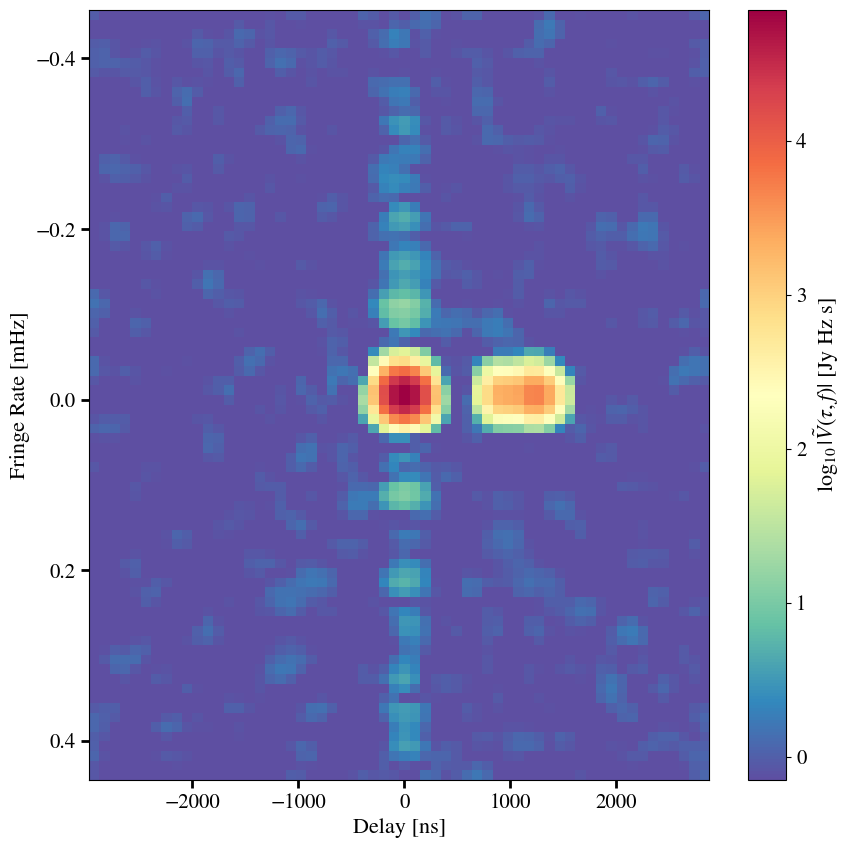

In [12]:
data_true_dlfr=plot_waterfalls(data_true, freqs*1e6, lsts, windows='blackman-harris', fig=None,ax=None, mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta',
                freq_window_kwargs=None, time_window_kwargs=None)[1]

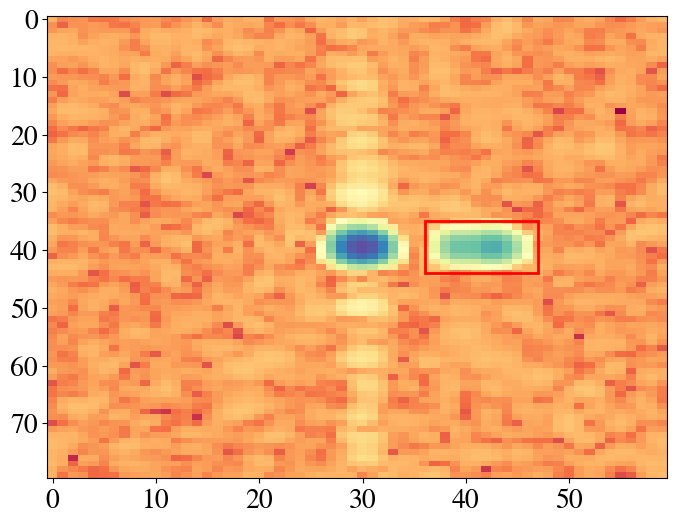

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8,6))

# im = ax.imshow(np.log10(np.abs(data_true_dlfr)), origin='lower', cmap='Spectral')
waterfall(data_true_dlfr, cmap='Spectral')

# Define the rectangle parameters
y0, y1 = 35, 44
x0, x1 = 36, 47
width = x1 - x0
height = y1 - y0

# Add rectangle patch (no fill, just border)
rect = patches.Rectangle(
    (x0, y0), width, height,
    linewidth=2, edgecolor='red', facecolor='none'
)
ax.add_patch(rect)

# plt.colorbar(im, ax=ax, label=r'$\log_{10}|V|$')
plt.show()

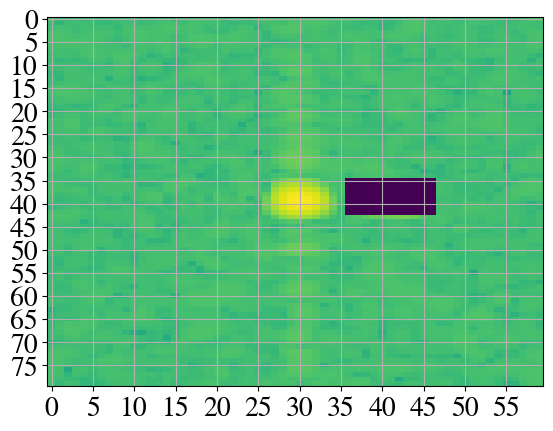

In [37]:
waterfall(data_true_dlfr[44:53,37:45])

masked_dlfr=data_true_dlfr.copy()
masked_dlfr[35:43,36:47]=1e-12

waterfall(masked_dlfr)
xticklocs=np.arange(0,60,5)
yticklocks=np.arange(0,80,5)
plt.xticks(xticklocs)
plt.yticks(yticklocks)
plt.grid()

In [38]:
masked_vis = iift_to_vis(masked_dlfr,freqs,lsts)

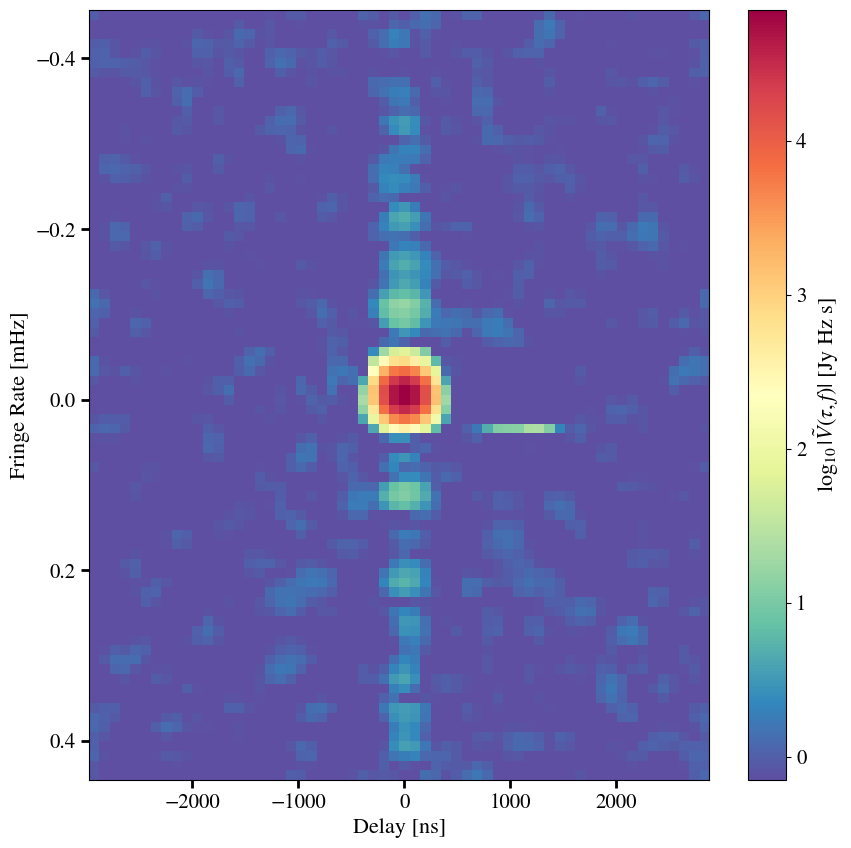

In [40]:
plot_op=plot_waterfalls(masked_vis, freqs*1e6, lsts, windows='blackman-harris', fig=None,ax=None, mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=True,
                freq_window_kwargs=None, time_window_kwargs=None)

In [41]:
np.save('./masked_data/masked_vis.npy',masked_vis)

# Filtering data

In [ ]:
dlys = fourier_freqs(freqs*1e6) * 1e9
freq_window = gen_window('blackman-harris',freqs.size)
data_dly = FFT(data_true*freq_window, axis=1)

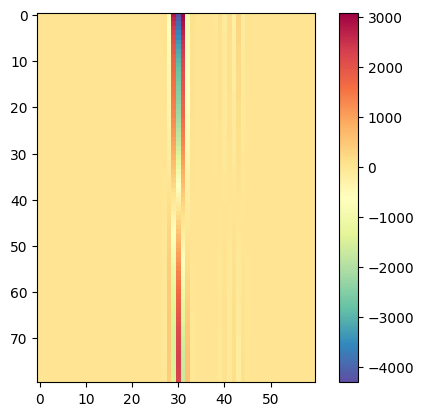

In [ ]:
plt.imshow(data_dly.real,cmap='Spectral_r')
plt.colorbar()

In [ ]:
import numpy as np

def svd_systematic_model_from_delay(
    data_td,                 # (Ntime, Ndelay) complex, delay-domain data (fftshifted along delay)
    delays_ns,               # (Ndelay,) delay axis in ns (fftshifted order)
    notch_halfwidth_ns=150.0, # Location of the center of the feature
    notch_weight=0.2,        # 0.0 is hard notch, everything else is soft notch. Assuming weights to be 0 < w < 1
    N_modes=10,
    use_shift=True,
    undo_window=None         # 1D freq window used in forward transform
):
    """
    This function does the following:
      - delay-only soft notch
      - SVD on down-weighted waterfall
      - reconstruct top N_modes
      - UNWEIGHT model back to original domain
      - inverse FFT (delay->freq) and subtract from original
    """
    Nt, Nd = data_td.shape
    delays_ns = np.asarray(delays_ns)

    mask = np.ones_like(delays_ns, dtype=float)
    low_edge  = 0 - notch_halfwidth_ns
    high_edge = 0 + notch_halfwidth_ns
    mask[(delays_ns >= low_edge) & (delays_ns <= high_edge)] = float(notch_weight)
    plt.plot(delays_ns,mask.real)
    # (2) delay soft notch
    # in_notch = np.abs(delays_ns) <= notch_halfwidth_ns
    # w_delay = np.ones_like(delays_ns, float)
    # w_delay[in_notch] = float(notch_weight)
    # W = mask[None, :]   # (1, Nd)
    W=mask
    # SVD on down-weighted
    data_td_dw = data_td * W
    U, S, Vh = np.linalg.svd(data_td_dw, full_matrices=False)
    r = min(N_modes, len(S))

    # Reconstruct IN THE WEIGHTED DOMAIN
    model_dw = U[:, :r] @ (S[:r, None] * Vh[:r, :])

    # *** UNWEIGHT the model so it lives in the *original* domain ***
    Wsafe = np.clip(W, 1e-6, None)
    model_td = model_dw / Wsafe

    # ---- back to frequency: model ----
    x = np.fft.ifftshift(model_td, axes=1) if use_shift else model_td
    model_tf = np.fft.ifft(x, axis=1)
    if use_shift:
        model_tf = np.fft.fftshift(model_tf, axes=1)
    if undo_window is not None:
        win = np.asarray(undo_window, float)
        model_tf = model_tf / np.clip(win[None, :], 1e-12, None)

    # ---- back to frequency: the data (for apples-to-apples subtraction) ----
    y = np.fft.ifftshift(data_td, axes=1) if use_shift else data_td
    data_tf = np.fft.ifft(y, axis=1)
    if use_shift:
        data_tf = np.fft.fftshift(data_tf, axes=1)
    if undo_window is not None:
        data_tf = data_tf / np.clip(win[None, :], 1e-12, None)

    cleaned_tf = data_tf - model_tf
    return model_td, model_tf, cleaned_tf


495.833333333333 1487.4999999999989


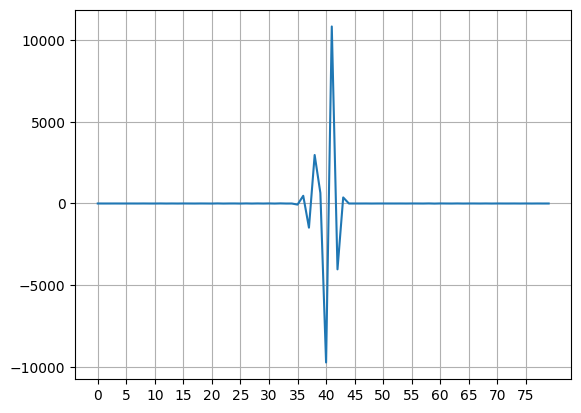

In [ ]:
plt.plot(data_true_dlfr[:,30].real)
plt.grid()
xticklocs=np.arange(0,80,5)
plt.xticks(xticklocs)
print(dlys[35],dlys[45])

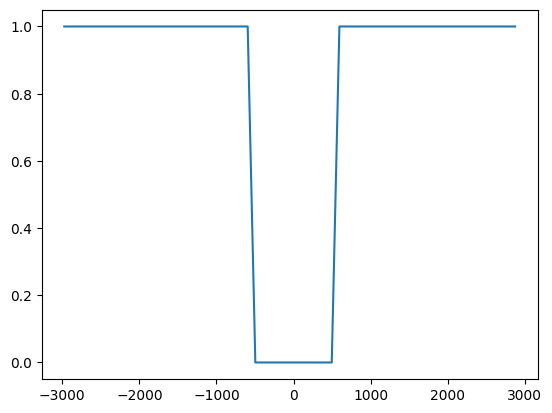

In [ ]:
# data_td: (Ntime, Ndelay) complex (your step-1 output)
# delays_ns: (Ndelay,) centered delay axis in ns (fftshifted)
# undo_window: the same frequency taper used during your forward transform (1D), or None.

model_td, model_tf, cleaned_tf = svd_systematic_model_from_delay(
    data_dly,
    dlys,
    # dl_center=150,
    notch_halfwidth_ns=500.0,  # choose based on your foreground wedge in tau
    notch_weight=0.0,         # hard mask; try 0.1–0.3 if you prefer soft down-weighting
    N_modes=4,                # number of modes you believe describe systematics
    use_shift=True,           # True if your delay spectra are fftshifted
    undo_window=freq_window          # or your Blackman-Harris window as 1D array length Nfreq
)

# cleaned_tf is what you’d subtract from your original freq-domain vis if you want to re-use the exact original:
# data_tf_clean = original_data_tf - model_tf


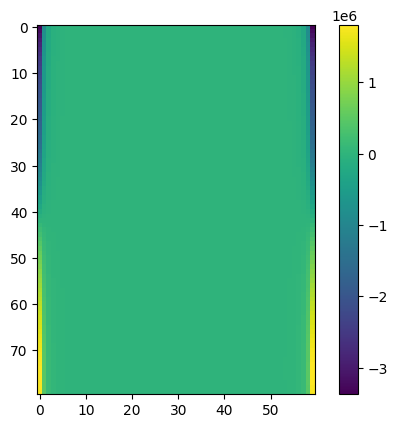

2875.833333333331 -2974.9999999999977


divide by zero encountered in log10


Text(0.5, 1.0, 'Difference')

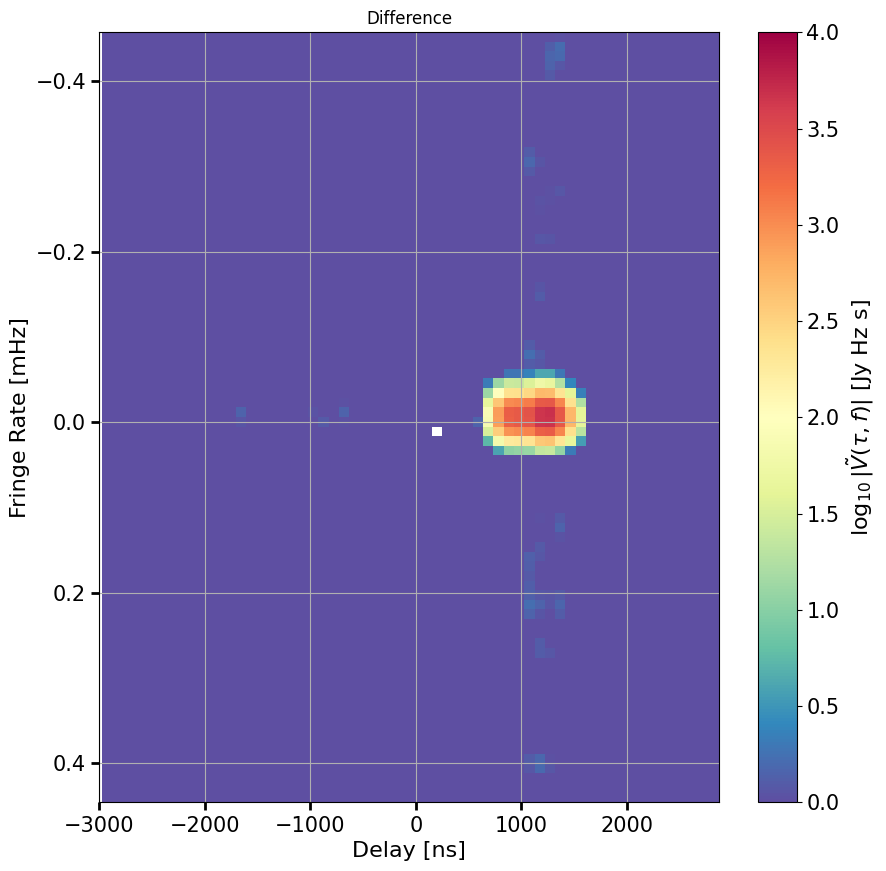

In [ ]:
data_unshifted = np.fft.ifftshift(model_td,axes=1)
temp = np.fft.ifft(data_unshifted,axis=1)
filtered_vis = temp / np.where(freq_window != 0, freq_window, eps)

_=plot_waterfalls(filtered_vis, freqs*1e6, lsts, windows='blackman-harris', fig=None,ax=None, mode='log', 
                vmin=0,vmax=4,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=True,
                freq_window_kwargs=None, time_window_kwargs=None)
plt.grid(which='both')
xticklocs=np.arange(-3000,3000,1000)
plt.xticks(xticklocs)
# plt.title("After filter")
plt.title("Difference")

2875.833333333331 -2974.9999999999977


Text(0.5, 1.0, 'After filtering')

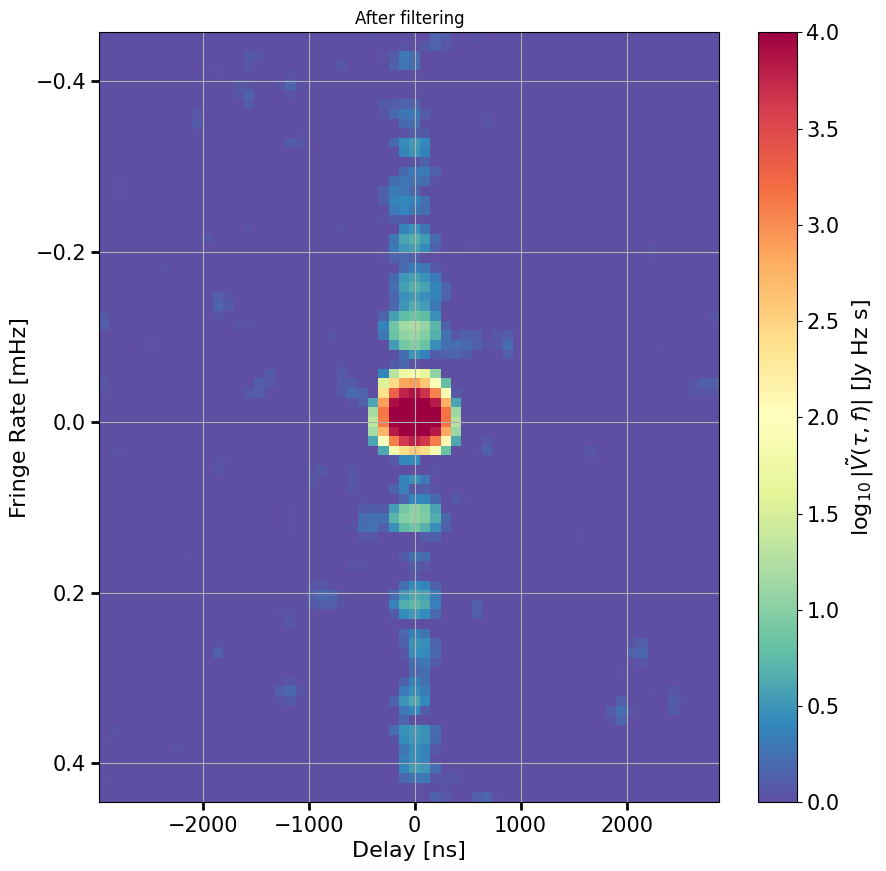

In [ ]:
data_unshifted = np.fft.ifftshift(data_dly-model_td,axes=1)
temp = np.fft.ifft(data_unshifted,axis=1)
filtered_vis = temp / np.where(freq_window != 0, freq_window, eps)

_=plot_waterfalls(filtered_vis, freqs*1e6, lsts, windows='blackman-harris', fig=None,ax=None, mode='log', 
                vmin=0,vmax=4,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=True,
                freq_window_kwargs=None, time_window_kwargs=None)
plt.grid(which='both')
# plt.title("After filter")
plt.title("After filtering")

2875.833333333331 -2974.9999999999977


Text(0.5, 1.0, 'Before filter')

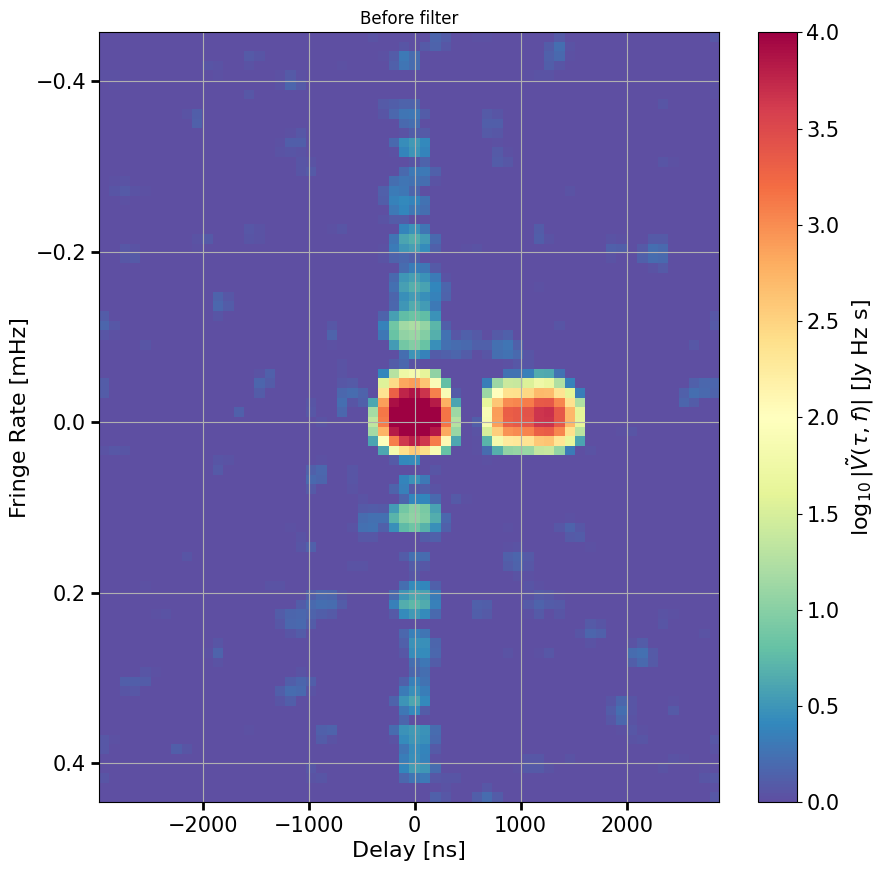

In [ ]:
_=plot_waterfalls(data_true, freqs*1e6, lsts, windows='blackman-harris', fig=None,ax=None, mode='log', 
                vmin=0,vmax=4,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=True,
                freq_window_kwargs=None, time_window_kwargs=None)
plt.grid()
plt.title("Before filter")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_svd_modes(data_td, delays_ns, notch_halfwidth_ns=150.0, notch_weight=0.2):
    """
    Recreate the SVD step used in your function and return U,S,Vh plus the delay weights W.
    """
    delays_ns = np.asarray(delays_ns)
    in_notch = np.abs(delays_ns) <= notch_halfwidth_ns
    w_delay = np.ones_like(delays_ns, float)
    w_delay[in_notch] = float(notch_weight)
    W = w_delay[None, :]  # (1, Ndelay) broadcast over time

    data_td_dw = data_td * W
    U, S, Vh = np.linalg.svd(data_td_dw, full_matrices=False)  # U: (Nt,r)  S: (r,)  Vh: (r,Nd)
    return U, S, Vh, W


def plot_svd_modes(U, S, Vh, delays_ns, times=None, N_show=6, magnitude='real'):
    """
    Plot (a) singular values + cumulative energy,
         (b) first N_show time and delay modes,
         (c) first N_show 2D per-mode templates U_k S_k V_k.

    magnitude: 'real'|'imag'|'abs' controls how complex arrays are displayed.
    """
    def disp(x):
        if magnitude == 'abs':  return np.abs(x)
        if magnitude == 'imag': return np.imag(x)
        return np.real(x)

    Nt, Nd = U.shape[0], Vh.shape[1]
    r = len(S)
    N_show = min(N_show, r)

    # # (a) Scree plot
    # fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    # ax[0].plot(np.arange(1, r+1), S, 'o-')
    # ax[0].set_xlabel('Mode index k')
    # ax[0].set_ylabel('Singular value S[k]')
    # ax[0].set_title('Scree plot')

    # energy = S**2
    # cum = np.cumsum(energy) / np.sum(energy)
    # ax[1].plot(np.arange(1, r+1), cum, 'o-')
    # ax[1].set_xlabel('Mode index k')
    # ax[1].set_ylabel('Cumulative energy')
    # ax[1].set_ylim(0, 1.05)
    # ax[1].grid(True, ls=':')
    # fig.tight_layout()

    # (b) First N_show 1-D modes (time and delay)
    fig, axes = plt.subplots(2, N_show, figsize=(5*N_show, 8), sharex='col')
    mpl.rcParams['font.size']=20
    if times is None:
        t_axis = np.arange(Nt)
        t_label = 'Time index'
    else:
        t_axis = np.asarray(times)
        t_label = 'Time'

    for k in range(N_show):
        # time mode (U)
        axes[0, k].plot(t_axis, disp(U[:, k]))
        axes[0, k].set_title('Time mode '+str(k))
        axes[0, k].set_xlabel(t_label)
        # delay mode (V)
        axes[1, k].plot(delays_ns, disp(Vh[k, :]))
        axes[1, k].set_title('Delay mode '+str(k))
        axes[1, k].set_xlabel(r'Delay $\tau$ [ns]')
    axes[0, 0].set_ylabel('Amplitude')
    axes[1, 0].set_ylabel('Amplitude')
    fig.suptitle('Leading SVD 1-D modes', y=1.02)
    fig.tight_layout()

    # (c) Per-mode 2D templates (outer products)
    fig, axes = plt.subplots(1, N_show, figsize=(8*N_show, 8),constrained_layout=True)
    mpl.rcParams['font.size']=20

    vmax = None
    # Precompute common color scale from the shown modes
    imgs = []
    for k in range(N_show):
        T = np.outer(U[:, k], Vh[k, :]) * S[k]
        imgs.append(disp(T))
    vmin = min(img.min() for img in imgs)
    vmax = max(img.max() for img in imgs)

    for k in range(N_show):
        T = imgs[k]
        axes[k].set_xscale('log')
        axes[k].set_yscale('log')
        im = axes[k].imshow(T, origin='lower', aspect='auto', vmin=-1, vmax=1, cmap='Spectral')
        axes[k].set_title(f'Mode {k}')
        axes[k].set_xlabel(r'$\tau$ [ns]')
        if k == 0:
            axes[k].set_ylabel('Time')
    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.9, pad=0.02)
    fig.suptitle('Per‑mode templates in delay domain', y=1.05)
    # fig.tight_layout()
    
    # ---- 1. Plot singular values ----
    plt.figure(figsize=(20, 4))
    mpl.rcParams['font.size']=10
    plt.semilogy(S, 'o-')
    plt.title("Singular values")
    plt.xlabel("Mode number")
    plt.ylabel("Singular value (log scale)")
    xticklocks = np.arange(0,65,5)
    plt.xticks(xticklocks)
    plt.grid(True)
    plt.show()

    return


Shapes: 
 U: (80, 60) 
 S: (60,) 
 V: (60, 60) 
 W: (1, 60)


Attempt to set non-positive xlim on a log-scaled axis will be ignored.
Attempt to set non-positive ylim on a log-scaled axis will be ignored.


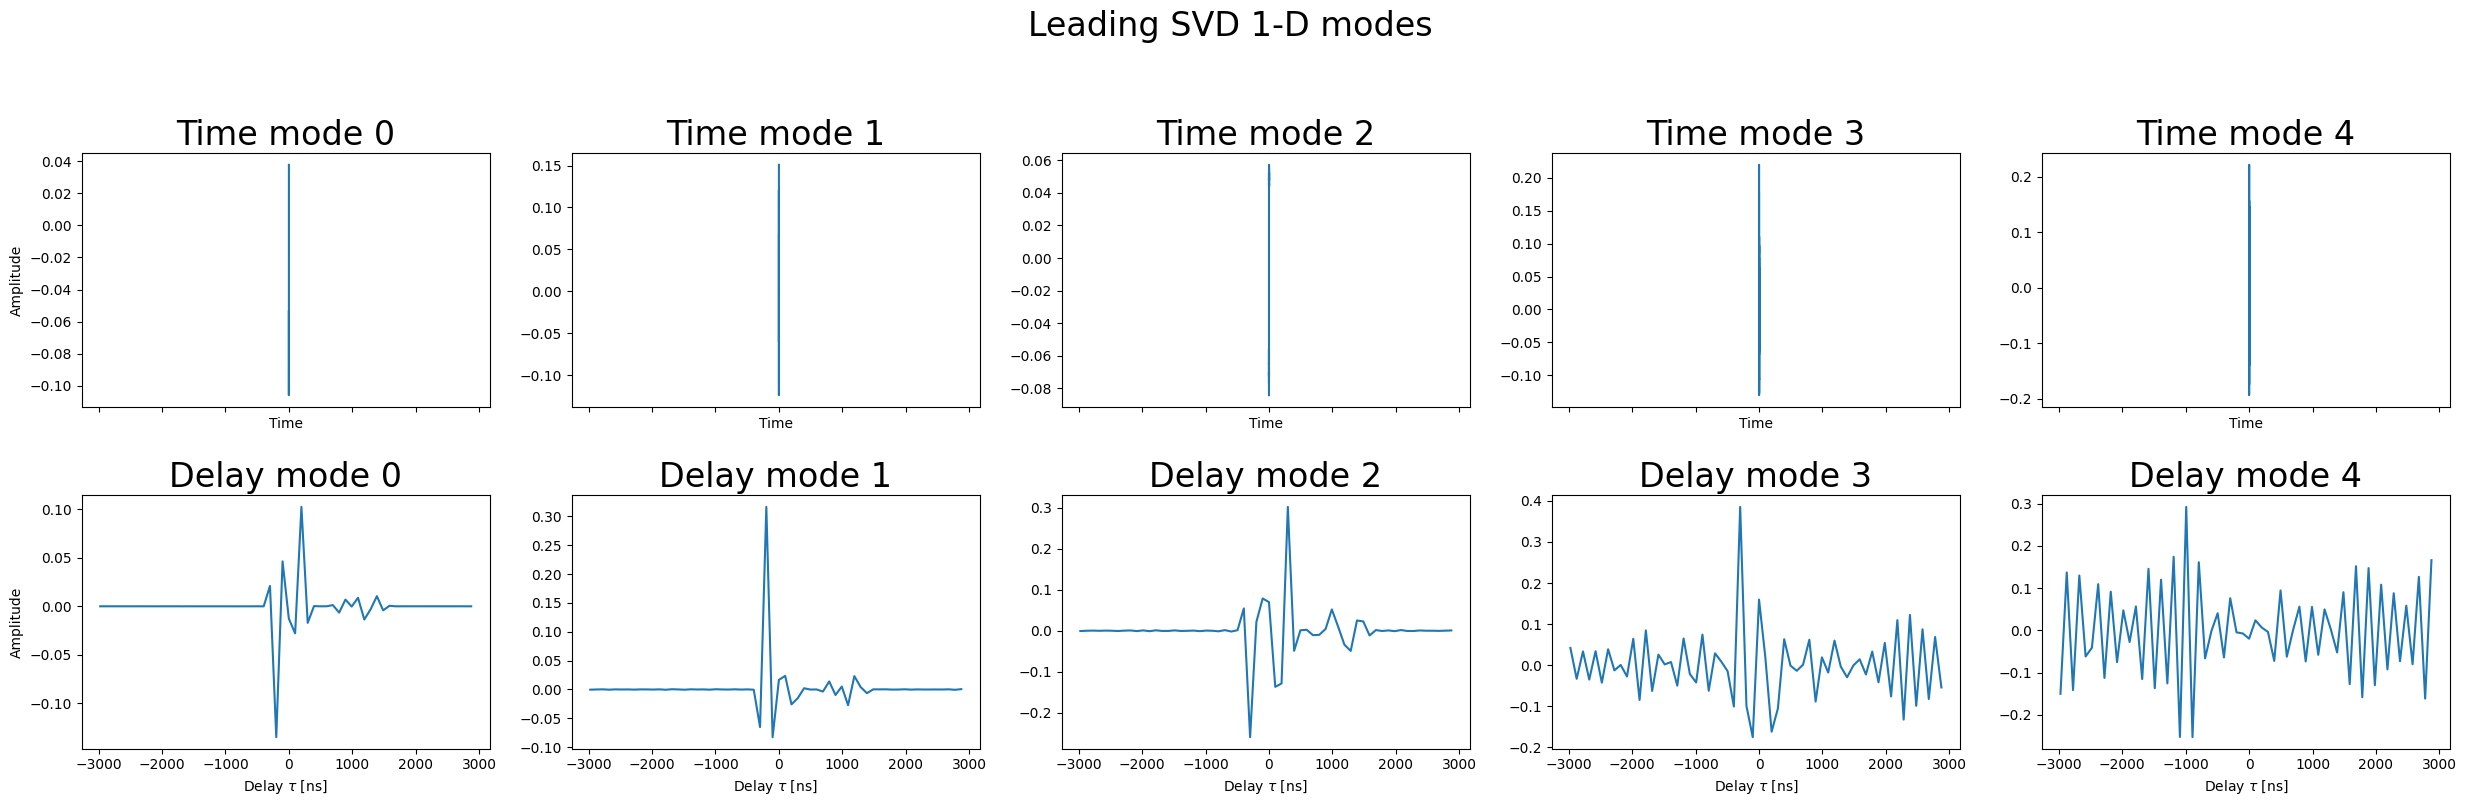

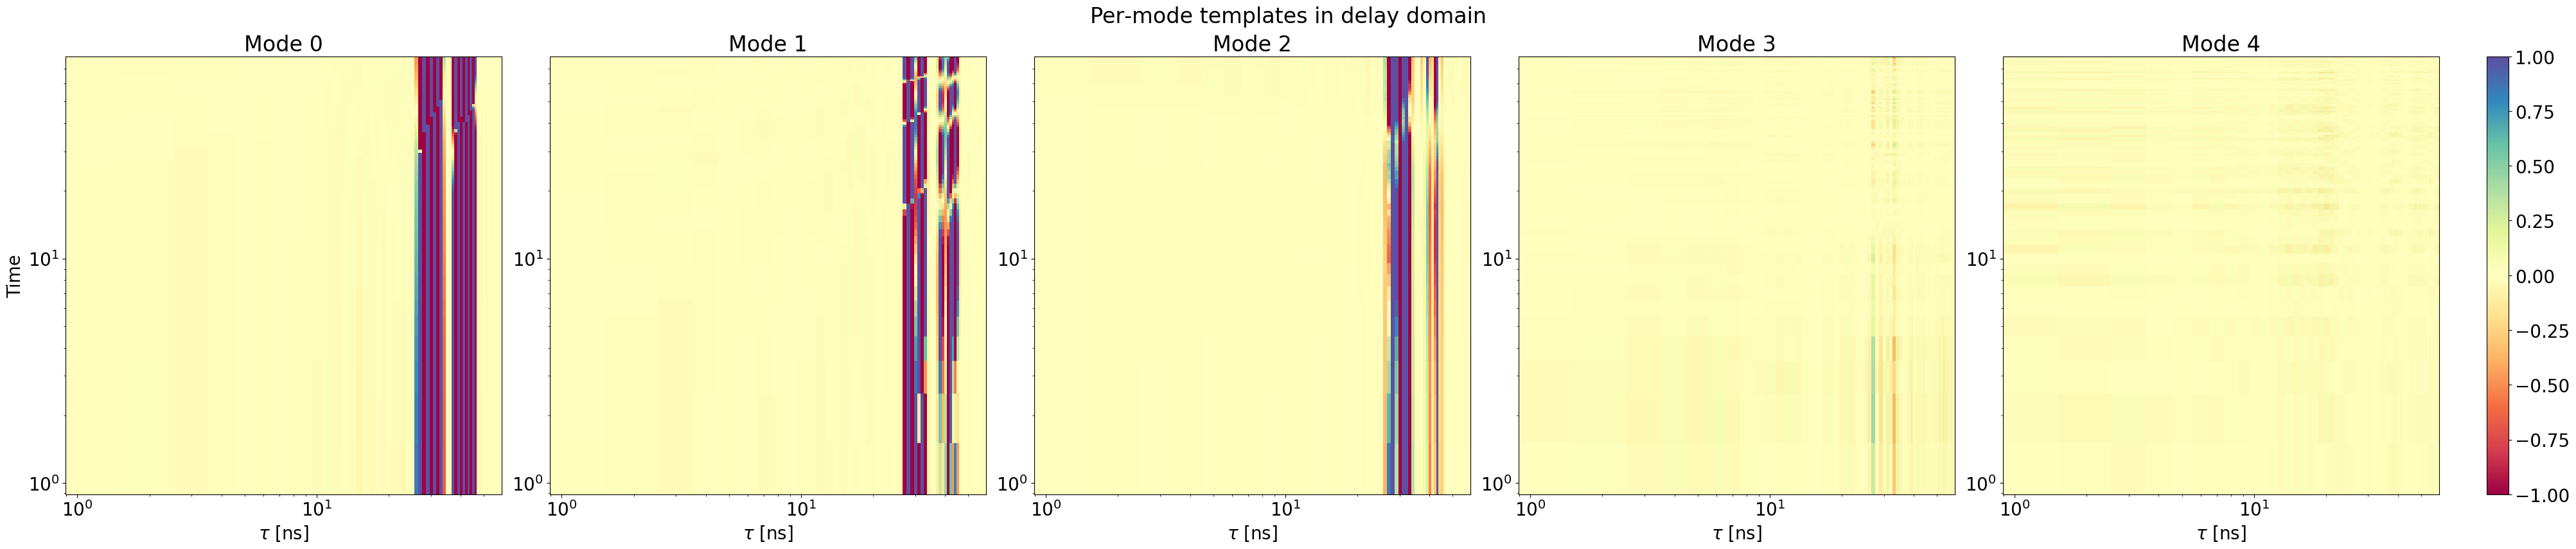

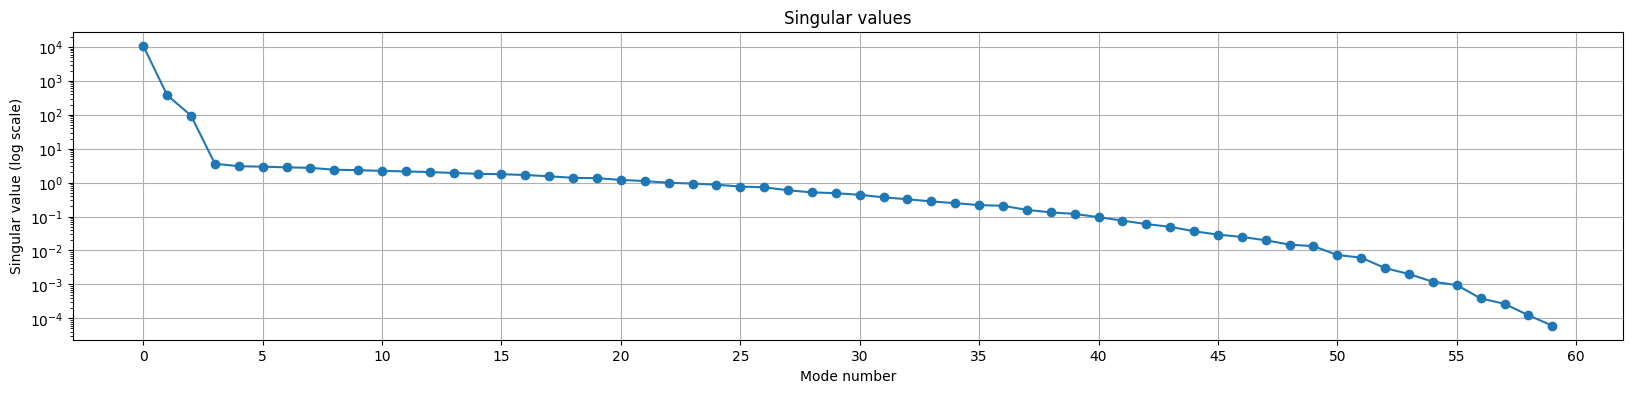

In [ ]:
# After you have data_dly (time × delay) and dlys (delay axis):
U, S, Vh, W = compute_svd_modes(
    data_td=data_dly,
    delays_ns=dlys,
    notch_halfwidth_ns=150.0,
    notch_weight=0.2
)
print("Shapes: \n U: {} \n S: {} \n V: {} \n W: {}".format(U.shape,S.shape,Vh.shape,W.shape))
# Plot the first, say, 8 modes
plot_svd_modes(U, S, Vh, delays_ns=dlys, times=lsts, N_show=5, magnitude='real')


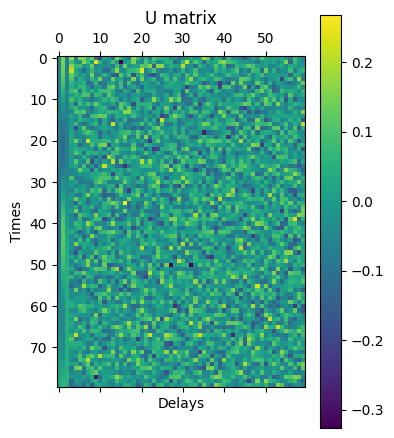

In [ ]:
plt.matshow(U.real)
plt.ylabel('Times')
plt.xlabel('Delays')
plt.title('U matrix')
plt.colorbar()

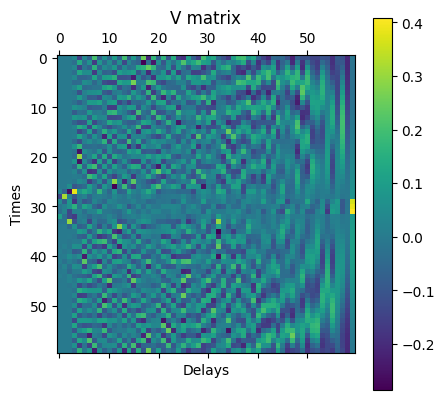

In [ ]:
plt.matshow(Vh.conj().T.real)
plt.ylabel('Times')
plt.xlabel('Delays')
plt.title('V matrix')
plt.colorbar()

# Plotting everything

NameError: name 'filtered_vis' is not defined

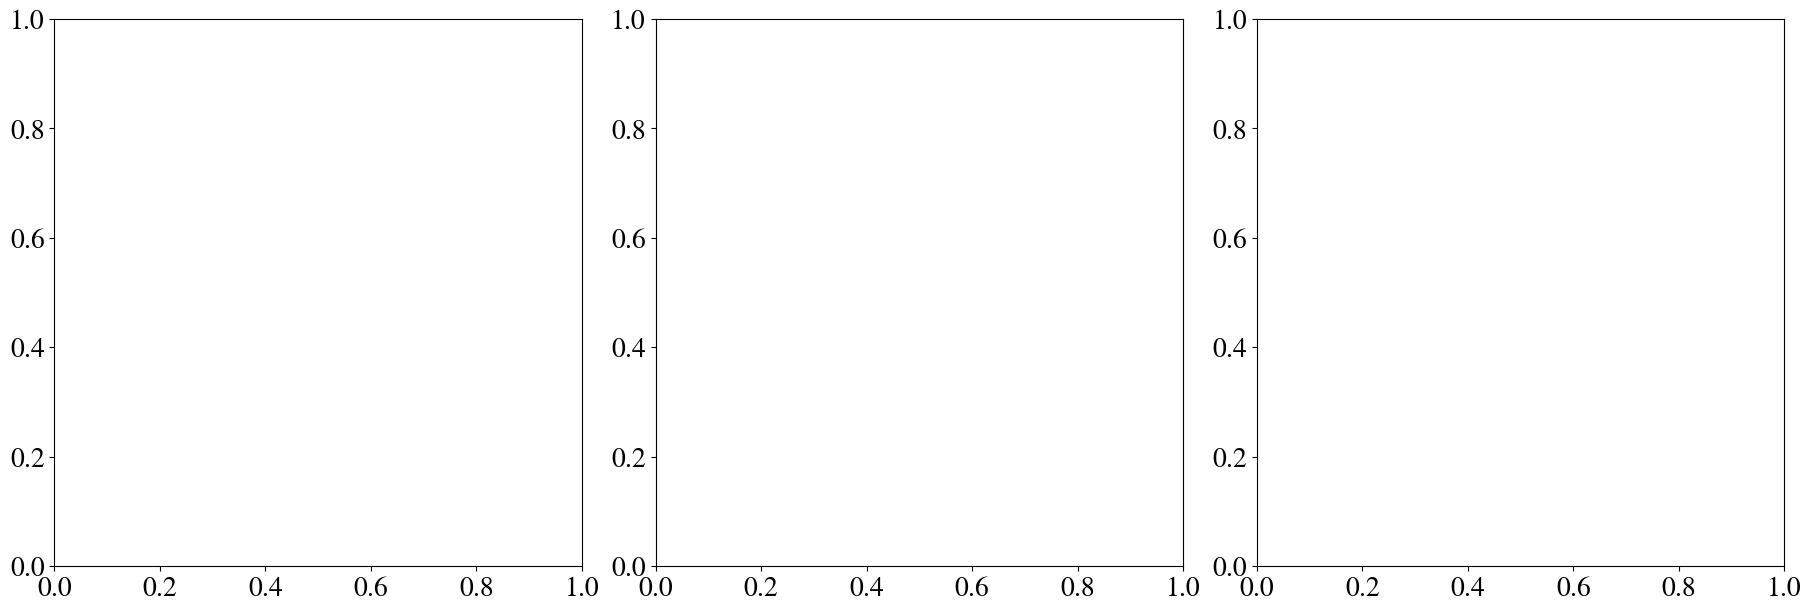

In [42]:
fig,axs = plt.subplots(1,3,layout="constrained",figsize=(18,6))
bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
i=0
data_arr=[data_true,masked_dlfr,filtered_vis]
fig_labels = ['True','Masked','Filtered']
plot_op=plot_waterfalls(data_true, freqs*1e6, lsts, windows='blackman-harris', fig=fig,ax=axs[0], mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=False,
                freq_window_kwargs=None, time_window_kwargs=None)
axs[0].text(0.95,0.07,fig_labels[0],fontsize=15, bbox=bbox,
            transform=axs[0].transAxes, horizontalalignment='right')

_=plot_waterfalls_from_dlfr(data_arr[1], freqs*1e6, lsts, fig=fig,ax=axs[1], mode='log', 
            vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all', colorbar_flag=False,
            baseline=None, horizon_color='magenta')
axs[1].text(0.95,0.07,fig_labels[1],fontsize=15, bbox=bbox,
        transform=axs[1].transAxes, horizontalalignment='right')

_=plot_waterfalls(filtered_vis, freqs*1e6, lsts, windows='blackman-harris', fig=fig,ax=axs[2], mode='log', 
                vmin=None,vmax=None,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=False,
                freq_window_kwargs=None, time_window_kwargs=None)
axs[2].text(0.95,0.07,fig_labels[2],fontsize=15, bbox=bbox,
            transform=axs[2].transAxes, horizontalalignment='right')

_=fig.colorbar(plot_op[0], ax=axs, orientation='vertical', fraction=0.9, pad=0.02)
vis_label = r"$\log_{10}|\tilde{V}(\tau, f)|$ [Jy Hz s]"
_.set_label(vis_label,c='black',fontsize=16)
# plt.savefig(result_dir+'/'+'method_comparison.pdf',bbox_inches='tight',dpi=300)

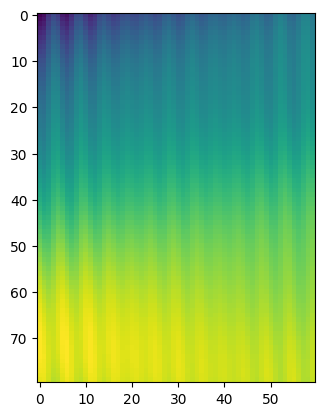

In [ ]:
plt.imshow(data_true.real)

In [ ]:
np.save('/Users/user/Documents/Codes/hydra_sys_project1/multi_phil/hydra-pspec-systematic/filtered_data/U_matrix.npy',U)
np.save('/Users/user/Documents/Codes/hydra_sys_project1/multi_phil/hydra-pspec-systematic/filtered_data/V_matrix.npy',Vh.conj().T)
np.save('/Users/user/Documents/Codes/hydra_sys_project1/multi_phil/hydra-pspec-systematic/filtered_data/S_vals.npy',S)
np.save('/Users/user/Documents/Codes/hydra_sys_project1/multi_phil/hydra-pspec-systematic/filtered_data/vis_sky_sys.npy',data_true)

In [ ]:
np.save('/Users/user/Documents/Codes/hydra_sys_project1/multi_phil/hydra-pspec-systematic/filtered_data/filtered_vis.npy',filtered_vis)

2875.833333333331 -2974.9999999999977
2875.833333333331 -2974.9999999999977
2875.833333333331 -2974.9999999999977


divide by zero encountered in log10


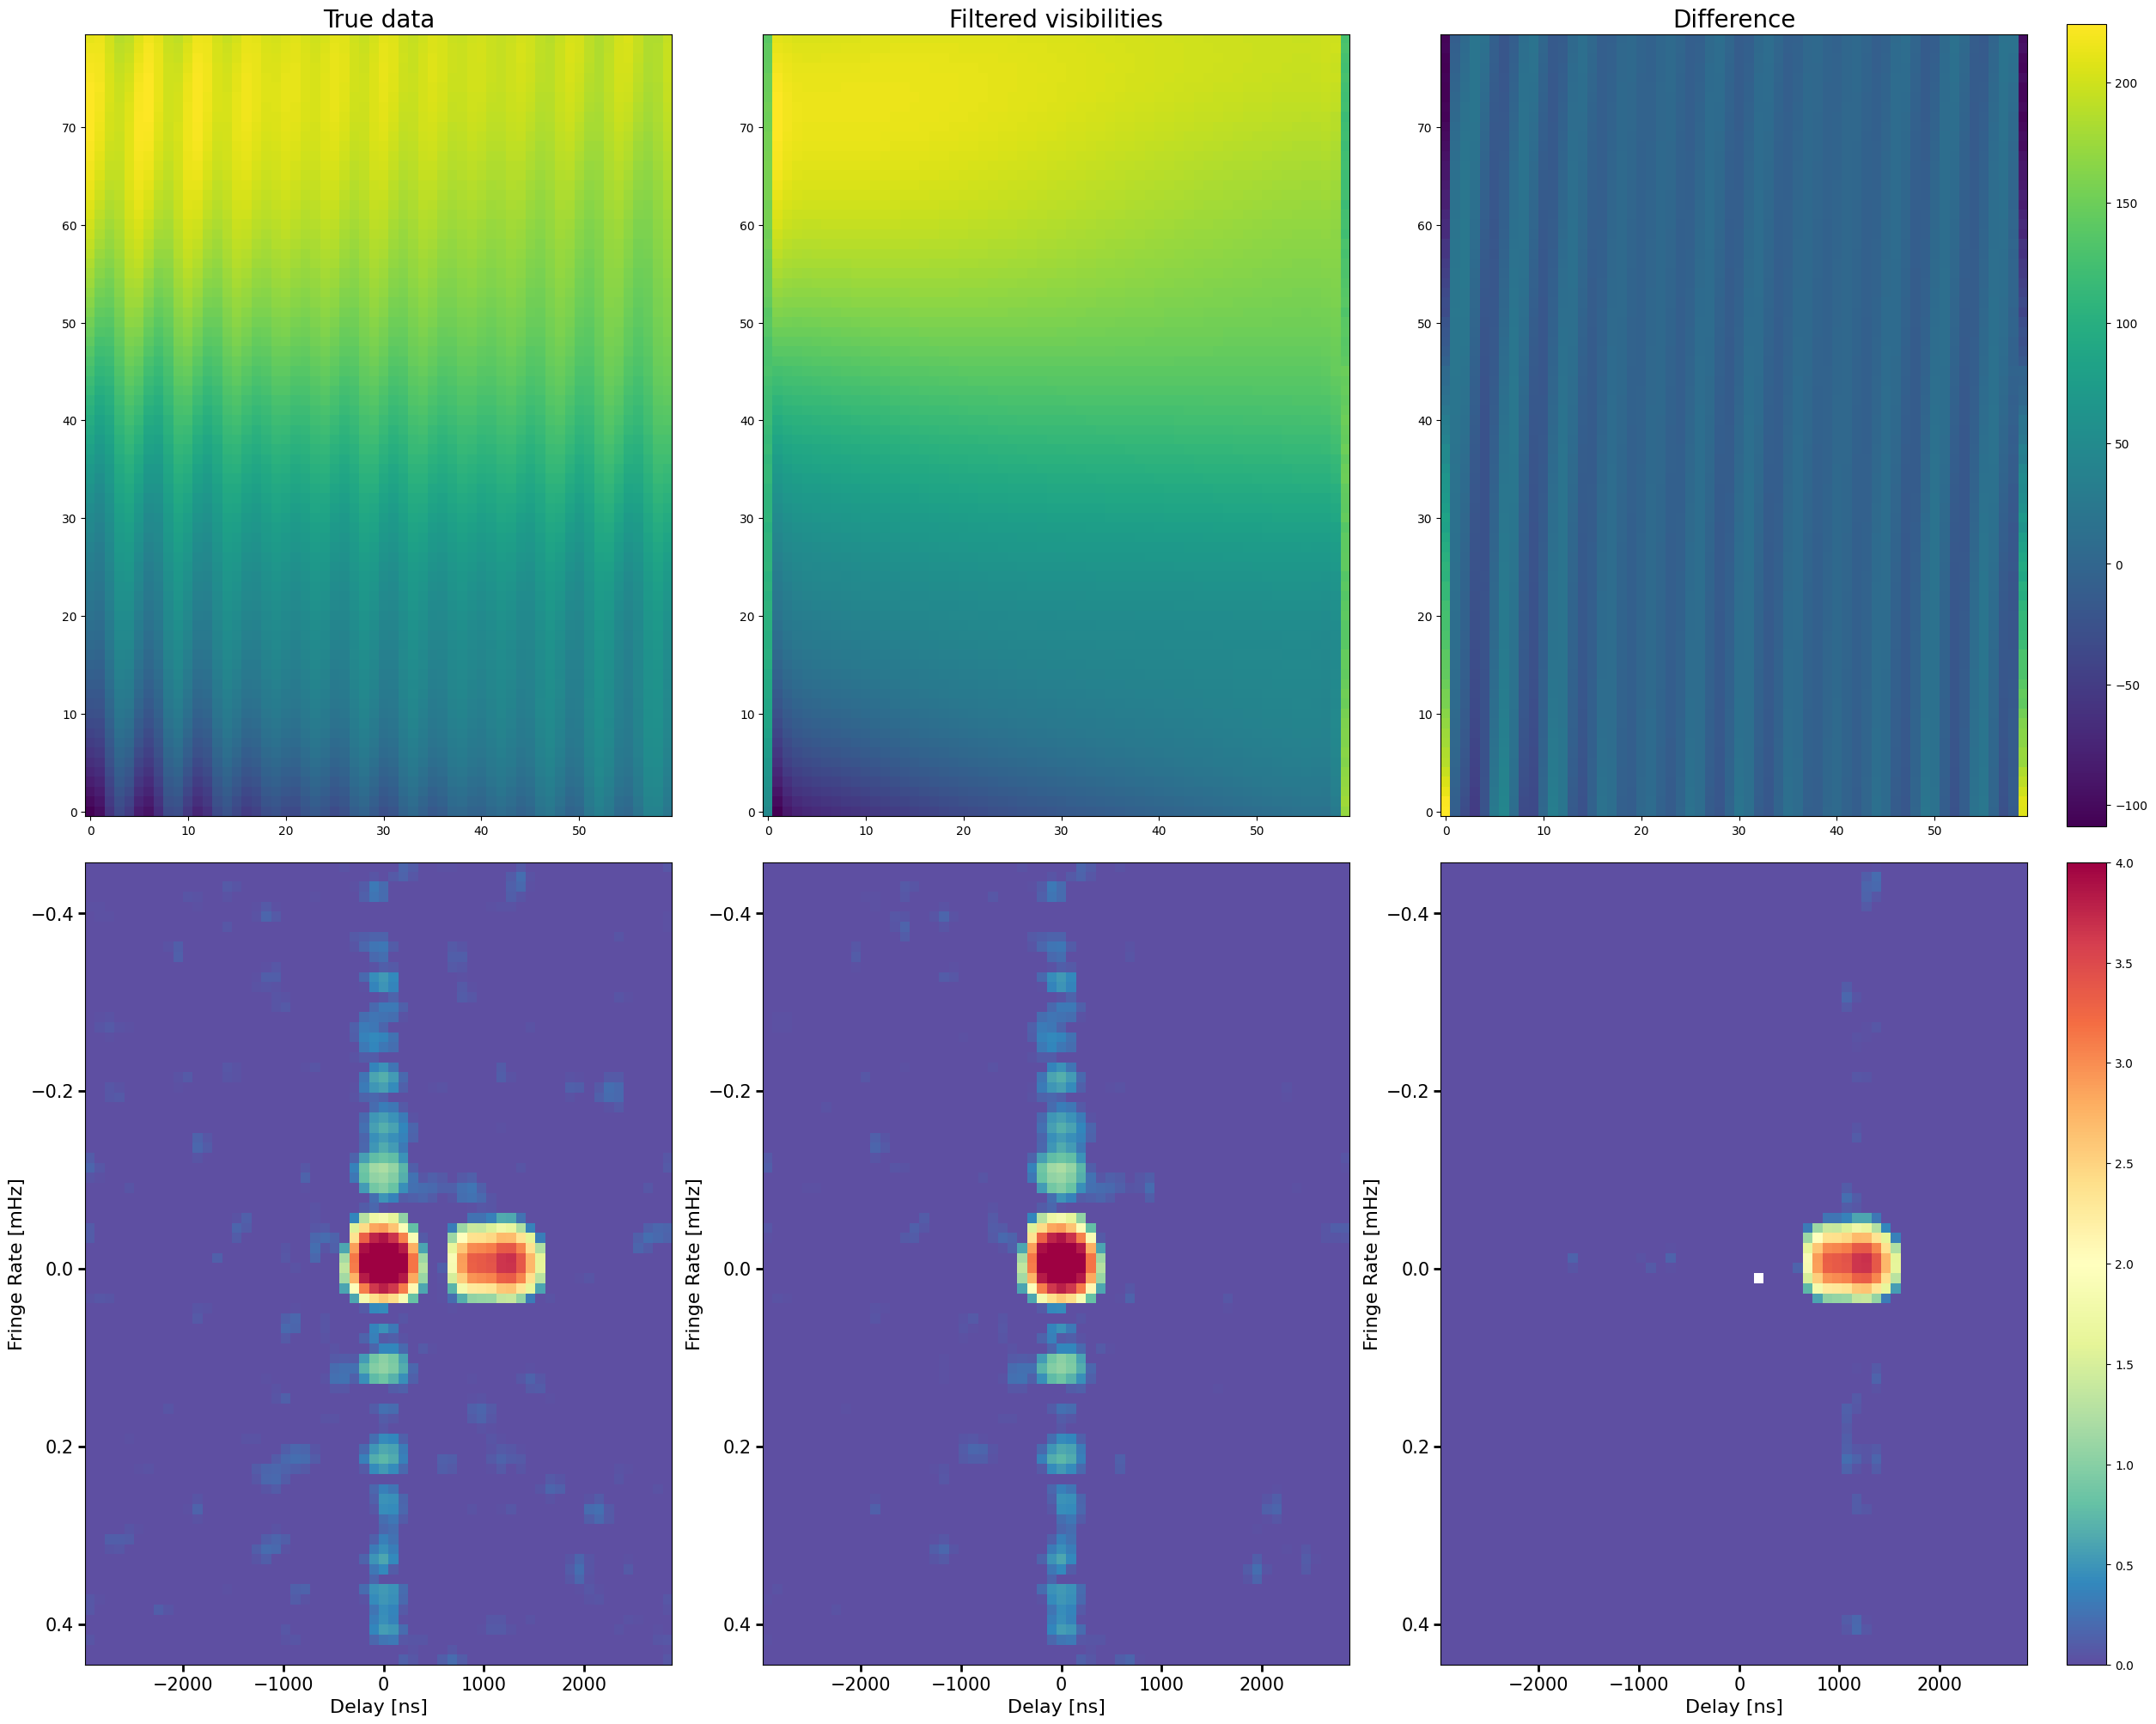

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(25,20), layout="constrained")
data_unshifted = np.fft.ifftshift(data_dly-model_td,axes=1)
temp = np.fft.ifft(data_unshifted,axis=1)
filtered_vis = temp / np.where(freq_window != 0, freq_window, eps)

data_unshifted = np.fft.ifftshift(model_td,axes=1)
temp = np.fft.ifft(data_unshifted,axis=1)
filter = temp / np.where(freq_window != 0, freq_window, eps)

im=axs[0,0].imshow(data_true.real,origin='lower')
axs[0,0].set_title("True data",fontsize=20)

im=axs[0,1].imshow(filtered_vis.real,origin='lower')
axs[0,1].set_title("Filtered visibilities",fontsize=20)

im=axs[0,2].imshow((filtered_vis-data_true).real,origin='lower')
axs[0,2].set_title("Difference",fontsize=20)

fig.colorbar(im, ax=axs[0,:], orientation='vertical', fraction=0.9, pad=0.02)

_=plot_waterfalls(data_true, freqs*1e6, lsts, windows='blackman-harris', fig=fig,ax=axs[1,0], mode='log', 
                vmin=0,vmax=4,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=False,
                freq_window_kwargs=None, time_window_kwargs=None)


_=plot_waterfalls(filtered_vis, freqs*1e6, lsts, windows='blackman-harris', fig=fig,ax=axs[1,1], mode='log', 
                vmin=0,vmax=4,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=False,
                freq_window_kwargs=None, time_window_kwargs=None)

_=plot_waterfalls(filter, freqs*1e6, lsts, windows='blackman-harris', fig=fig,ax=axs[1,2], mode='log', 
                vmin=0,vmax=4,cmap='Spectral_r', dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=False,
                freq_window_kwargs=None, time_window_kwargs=None)
fig.colorbar(_[0], ax=axs[1,:], orientation='vertical', fraction=0.9, pad=0.02)


TypeError: Colorbar.__init__() got an unexpected keyword argument 'axis'

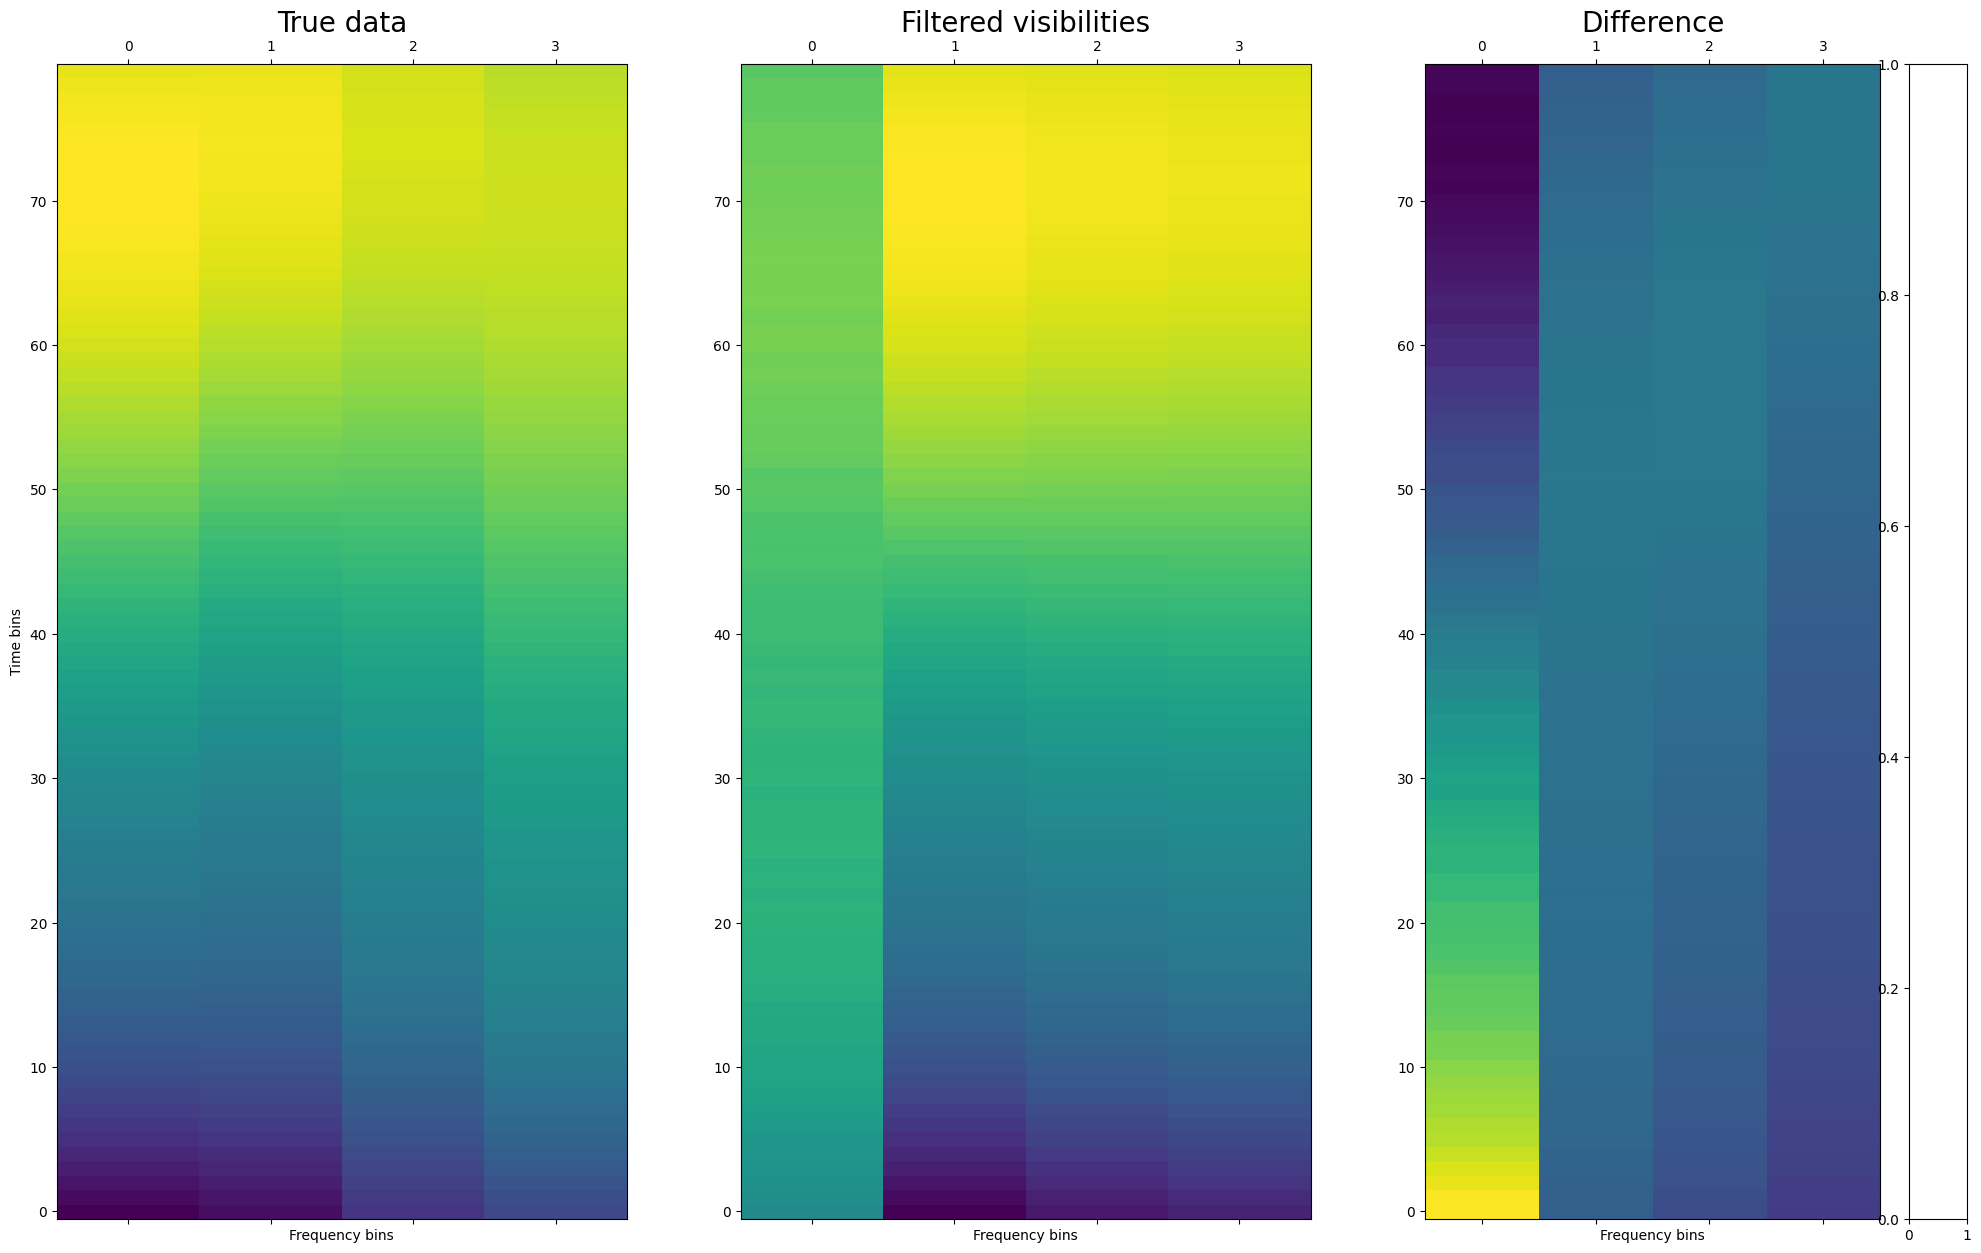

In [ ]:
fig,axs=plt.subplots(1,3,figsize=(25,15))

im=axs[0].matshow(data_true[:,:4].real,origin='lower',aspect='auto')
axs[0].set_title("True data",fontsize=20)
axs[0].set_xlabel('Frequency bins')
axs[0].set_ylabel('Time bins')

im=axs[1].matshow(filtered_vis[:,:4].real,origin='lower',aspect='auto')
axs[1].set_title("Filtered visibilities",fontsize=20)
axs[1].set_xlabel('Frequency bins')

im=axs[2].matshow((filtered_vis-data_true)[:,:4].real,origin='lower',aspect='auto')
axs[2].set_title("Difference",fontsize=20)
axs[2].set_xlabel('Frequency bins')

plt.colorbar(im,axis=axs)

In [ ]:
dict = {}
for el in f:
    key = el.split('_')[2]
    val = el
    dict[key]= val